# Model Selection

In [27]:
import pickle as pkl

X_train = pkl.load(open("../../../data/processed/vbac/X_train_prepared.pkl", "rb"))
X_test = pkl.load(open("../../../data/processed/vbac/X_test_prepared.pkl", "rb"))
y_test = pkl.load(open("../../../data/processed/vbac/y_test.pkl", "rb"))
y_train = pkl.load(open("../../../data/processed/vbac/y_train.pkl", "rb"))

First, we'll train a basic logistic regression model.

In [13]:
from sklearn.linear_model import LogisticRegression

log_reg_model = LogisticRegression(random_state=14, max_iter=1000)

log_reg_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",14
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [14]:
predictions = log_reg_model.predict(X_test)

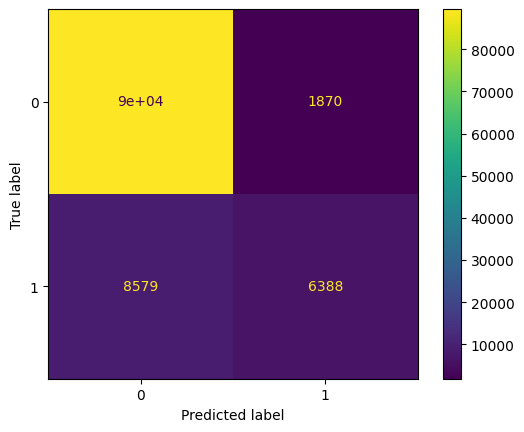

In [15]:
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=log_reg_model.classes_
)
disp.plot()
plt.show()

Our confusion matrix indicates that our model has a high false-negative rate.

In [16]:
from sklearn.metrics import f1_score

log_reg_f1 = f1_score(y_test, predictions)

log_reg_f1

0.550096878363832

Next we'll train a random forest classifier.

In [17]:
from sklearn.ensemble import RandomForestClassifier

rfc_model = RandomForestClassifier(random_state=14, max_depth=5)

rfc_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [18]:
predictions_rfc = rfc_model.predict(X_test)

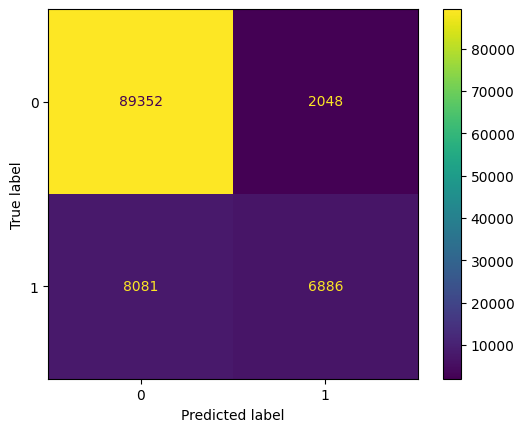

In [ ]:
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predictions_rfc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rfc_model.classes_)
disp.plot()
plt.show()

In [20]:
from sklearn.metrics import f1_score

rfc_f1 = f1_score(y_test, predictions_rfc)

rfc_f1

0.5762102004100247

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

nn_model = Sequential()
nn_model.add(Dense(64, input_dim=X_train.shape[1], activation="relu"))
nn_model.add(Dense(32, activation="relu"))
nn_model.add(Dense(1, activation="sigmoid"))

nn_model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

nn_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=100,
    validation_data=(X_test, y_test),
)

Epoch 1/10


/home/akrucken/dev/natality-stats/dev/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4255/4255 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9040 - loss: 0.2591 - val_accuracy: 0.9060 - val_loss: 0.2528
Epoch 2/10
4255/4255 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9064 - loss: 0.2537 - val_accuracy: 0.9066 - val_loss: 0.2516
Epoch 3/10
4255/4255 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - accuracy: 0.9065 - loss: 0.2525 - val_accuracy: 0.9067 - val_loss: 0.2522
Epoch 4/10
4255/4255 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9068 - loss: 0.2516 - val_accuracy: 0.9071 - val_loss: 0.2499
Epoch 5/10
4255/4255 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9069 - loss: 0.2511 - val_accuracy: 0.9074 - val_loss: 0.2494
Epoch 6/10
4255/4255 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9072 - loss: 0.2508 - val_accuracy: 0.9070 - val_loss: 0.2499
Epoch 7/10
4255/4255 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9071 - loss: 0.2504 - val_accuracy: 0.9071 - val_loss: 0.2489
Epoch 8/10
4255/4255 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9071 - loss: 0.2503 - val_

In [22]:
predictions_nn = nn_model.predict(X_test)
predictions_nn = (predictions_nn > 0.5).astype(int)

3324/3324 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step


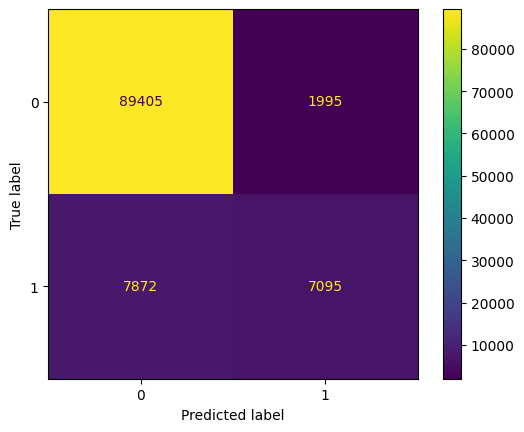

In [23]:
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predictions_nn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot()
plt.show()

In [24]:
from sklearn.metrics import f1_score

nn_f1 = f1_score(y_test, predictions_nn)

nn_f1

0.5898491083676269

In [25]:
print("Logistic Regression F1 score: ", log_reg_f1)
print("RFC F1 score: ", rfc_f1)
print("NN F1 score: ", nn_f1)

Logistic Regression F1 score:  0.550096878363832
RFC F1 score:  0.5762102004100247
NN F1 score:  0.5898491083676269


### Conclusion

The neural network performs best, but none of the models perform especially well. Because of bundle size limitations preventing deployment of a keras model, we'll deploy the RFC.

In [28]:
pkl.dump(rfc_model, open("../../../models/vbac/rfc_model.pkl", "wb"))